In [20]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
df_prices = pd.read_csv("ETF prices.csv")

df_prices.head()

,fund_symbol,price_date,open,high,low,close,adj_close,volume
0,AAA,2020-09-09,25.10,25.12,25.07,25.07,24.85,17300
1,AAA,2020-09-10,25.06,25.07,25.05,25.07,24.85,23500
2,AAA,2020-09-11,25.04,25.05,25.02,25.03,24.81,33400
3,AAA,2020-09-14,25.01,25.06,25.01,25.02,24.80,13100
4,AAA,2020-09-15,25.02,25.03,25.01,25.01,24.79,12100


In [9]:
df_prices.shape
df_prices.columns
df_prices["fund_symbol"].unique()[:20]

array(['AAA', 'AAAU', 'AADR', 'AAXJ', 'ABEQ', 'ACES', 'ACIO', 'ACSI',
       'ACTV', 'ACVF', 'ACWF', 'ACWI', 'ACWV', 'ACWX', 'ADFI', 'ADIV',
       'ADME', 'ADRE', 'AEMB', 'AESR'], dtype=object)

In [10]:
df_etf = df_prices[df_prices["fund_symbol"] == "AAXJ"]

df_etf.head()

,fund_symbol,price_date,open,high,low,close,adj_close,volume
4002,AAXJ,2008-08-15,50.13,50.13,50.13,50.13,40.23,100
4003,AAXJ,2008-08-18,49.77,49.77,49.00,49.00,39.32,25600
4004,AAXJ,2008-08-19,48.34,48.34,48.34,48.34,38.79,100
4005,AAXJ,2008-08-20,49.05,49.05,49.02,49.02,39.34,4000
4006,AAXJ,2008-08-21,49.02,49.02,49.02,49.02,39.34,0


In [11]:
df_etf.shape

(3347, 8)

In [13]:
df_etf.loc[:, "price_date"] = pd.to_datetime(df_etf["price_date"])

In [14]:
df_etf = df_etf.sort_values("price_date")

df_etf.head()

,fund_symbol,price_date,open,high,low,close,adj_close,volume
4002,AAXJ,2008-08-15,50.13,50.13,50.13,50.13,40.23,100
4003,AAXJ,2008-08-18,49.77,49.77,49.00,49.00,39.32,25600
4004,AAXJ,2008-08-19,48.34,48.34,48.34,48.34,38.79,100
4005,AAXJ,2008-08-20,49.05,49.05,49.02,49.02,39.34,4000
4006,AAXJ,2008-08-21,49.02,49.02,49.02,49.02,39.34,0


In [15]:
df_etf["return"] = df_etf["adj_close"].pct_change()

df_etf.head()

,fund_symbol,price_date,open,high,low,close,adj_close,volume,return
4002,AAXJ,2008-08-15,50.13,50.13,50.13,50.13,40.23,100,NaN
4003,AAXJ,2008-08-18,49.77,49.77,49.00,49.00,39.32,25600,-0.022620
4004,AAXJ,2008-08-19,48.34,48.34,48.34,48.34,38.79,100,-0.013479
4005,AAXJ,2008-08-20,49.05,49.05,49.02,49.02,39.34,4000,0.014179
4006,AAXJ,2008-08-21,49.02,49.02,49.02,49.02,39.34,0,0.000000


In [16]:
df_etf = df_etf.dropna()

In [18]:
df_etf["return"] = df_etf["adj_close"].pct_change()

df_etf.head()

,fund_symbol,price_date,open,high,low,close,adj_close,volume,return
4003,AAXJ,2008-08-18,49.77,49.77,49.00,49.00,39.32,25600,NaN
4004,AAXJ,2008-08-19,48.34,48.34,48.34,48.34,38.79,100,-0.013479
4005,AAXJ,2008-08-20,49.05,49.05,49.02,49.02,39.34,4000,0.014179
4006,AAXJ,2008-08-21,49.02,49.02,49.02,49.02,39.34,0,0.000000
4007,AAXJ,2008-08-22,49.25,49.25,49.16,49.22,39.50,3600,0.004067


In [19]:
df_etf = df_etf.dropna()

df_etf.head()

,fund_symbol,price_date,open,high,low,close,adj_close,volume,return
4004,AAXJ,2008-08-19,48.34,48.34,48.34,48.34,38.79,100,-0.013479
4005,AAXJ,2008-08-20,49.05,49.05,49.02,49.02,39.34,4000,0.014179
4006,AAXJ,2008-08-21,49.02,49.02,49.02,49.02,39.34,0,0.000000
4007,AAXJ,2008-08-22,49.25,49.25,49.16,49.22,39.50,3600,0.004067
4008,AAXJ,2008-08-25,49.19,49.19,48.30,48.30,38.76,17000,-0.018734


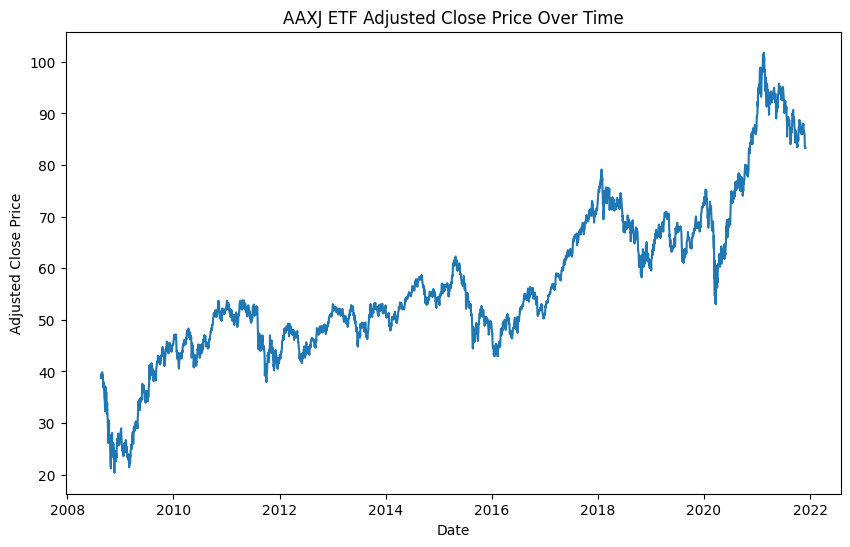

In [21]:
plt.figure(figsize=(10,6))
plt.plot(df_etf["price_date"], df_etf["adj_close"])

plt.title("AAXJ ETF Adjusted Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")

plt.show()

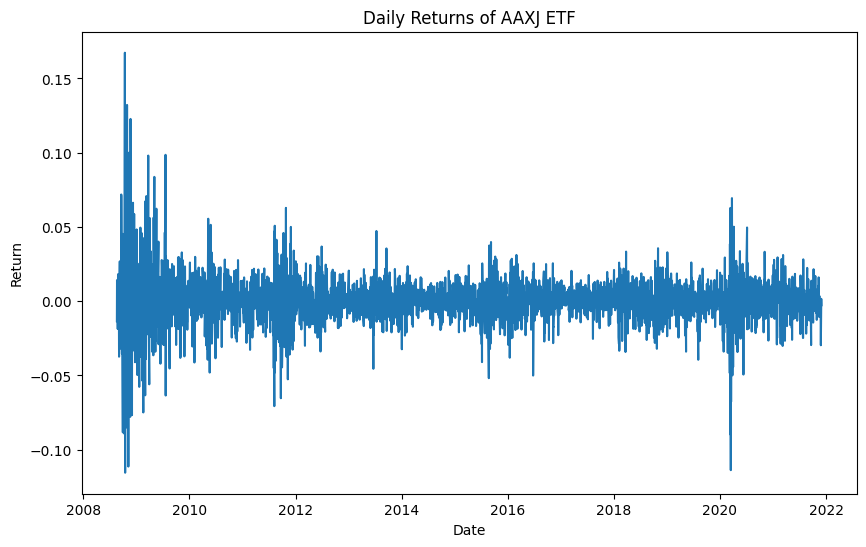

In [22]:
plt.figure(figsize=(10,6))
plt.plot(df_etf["price_date"], df_etf["return"])

plt.title("Daily Returns of AAXJ ETF")
plt.xlabel("Date")
plt.ylabel("Return")

plt.show()

In [23]:
df_etf["lag1"] = df_etf["return"].shift(1)
df_etf["lag2"] = df_etf["return"].shift(2)

df_etf.head()

,fund_symbol,price_date,open,high,low,close,adj_close,volume,return,lag1,lag2
4004,AAXJ,2008-08-19,48.34,48.34,48.34,48.34,38.79,100,-0.013479,NaN,NaN
4005,AAXJ,2008-08-20,49.05,49.05,49.02,49.02,39.34,4000,0.014179,-0.013479,NaN
4006,AAXJ,2008-08-21,49.02,49.02,49.02,49.02,39.34,0,0.000000,0.014179,-0.013479
4007,AAXJ,2008-08-22,49.25,49.25,49.16,49.22,39.50,3600,0.004067,0.000000,0.014179
4008,AAXJ,2008-08-25,49.19,49.19,48.30,48.30,38.76,17000,-0.018734,0.004067,0.000000


In [24]:
df_etf = df_etf.dropna()

df_etf.head()

,fund_symbol,price_date,open,high,low,close,adj_close,volume,return,lag1,lag2
4006,AAXJ,2008-08-21,49.02,49.02,49.02,49.02,39.34,0,0.000000,0.014179,-0.013479
4007,AAXJ,2008-08-22,49.25,49.25,49.16,49.22,39.50,3600,0.004067,0.000000,0.014179
4008,AAXJ,2008-08-25,49.19,49.19,48.30,48.30,38.76,17000,-0.018734,0.004067,0.000000
4009,AAXJ,2008-08-26,48.92,48.92,48.55,48.76,39.13,5000,0.009546,-0.018734,0.004067
4010,AAXJ,2008-08-27,49.77,49.77,49.65,49.65,39.84,1500,0.018145,0.009546,-0.018734


In [25]:
X = df_etf[["lag1", "lag2"]]
y = df_etf["return"]

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [27]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [28]:
y_pred = model.predict(X_test)

In [29]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 0.014849298448882981
R2: -0.018488188855863674


Polynomial Regression

In [30]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("linear", LinearRegression())
])

poly_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('poly', ...), ('linear', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


In [31]:
y_pred_poly = poly_model.predict(X_test)

In [32]:
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("Polynomial RMSE:", rmse_poly)
print("Polynomial R2:", r2_poly)

Polynomial RMSE: 0.014723870632407238
Polynomial R2: -0.0013550926663370433


In [33]:
df_etf["direction"] = (df_etf["return"] > 0).astype(int)

df_etf.head()

,fund_symbol,price_date,open,high,low,close,adj_close,volume,return,lag1,lag2,direction
4006,AAXJ,2008-08-21,49.02,49.02,49.02,49.02,39.34,0,0.000000,0.014179,-0.013479,0
4007,AAXJ,2008-08-22,49.25,49.25,49.16,49.22,39.50,3600,0.004067,0.000000,0.014179,1
4008,AAXJ,2008-08-25,49.19,49.19,48.30,48.30,38.76,17000,-0.018734,0.004067,0.000000,0
4009,AAXJ,2008-08-26,48.92,48.92,48.55,48.76,39.13,5000,0.009546,-0.018734,0.004067,1
4010,AAXJ,2008-08-27,49.77,49.77,49.65,49.65,39.84,1500,0.018145,0.009546,-0.018734,1


In [34]:
X = df_etf[["lag1", "lag2"]]
y_class = df_etf["direction"]

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, shuffle=False
)

In [36]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()

log_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [37]:
y_pred_class = log_model.predict(X_test)

In [38]:
from sklearn.metrics import accuracy_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred_class)

print("Accuracy:", accuracy)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_class))

Accuracy: 0.5366218236173393
Confusion Matrix:
[[  0 310]
 [  0 359]]


In [39]:
df_etf["direction"].value_counts(normalize=True)

direction
1    0.52767
0    0.47233
Name: proportion, dtype: float64

In [40]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge RMSE:", rmse_ridge)
print("Ridge R2:", r2_ridge)

Ridge RMSE: 0.49843031520051595
Ridge R2: 0.0009091288377474083


In [41]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.001)

lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso RMSE:", rmse_lasso)
print("Lasso R2:", r2_lasso)

Lasso RMSE: 0.4987826154188556
Lasso R2: -0.0005037239299774399


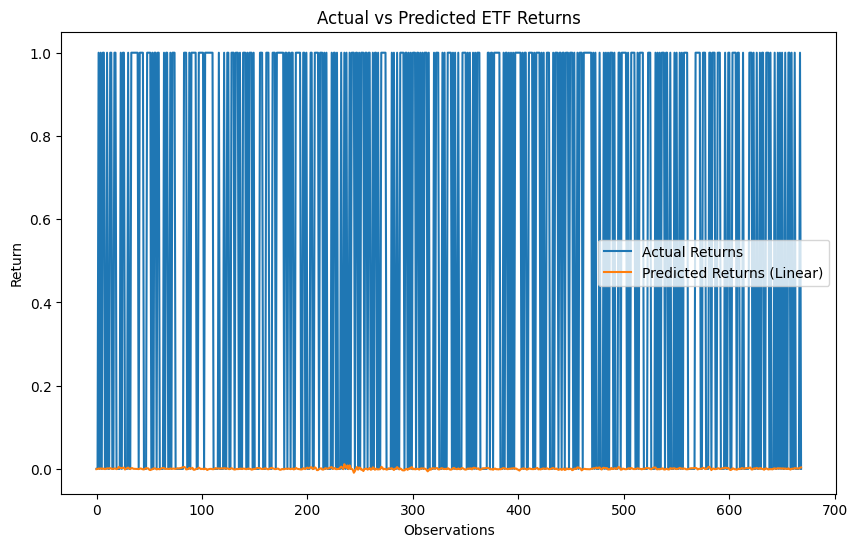

In [42]:
plt.figure(figsize=(10,6))

plt.plot(y_test.values, label="Actual Returns")
plt.plot(y_pred, label="Predicted Returns (Linear)")

plt.title("Actual vs Predicted ETF Returns")
plt.xlabel("Observations")
plt.ylabel("Return")

plt.legend()

plt.show()

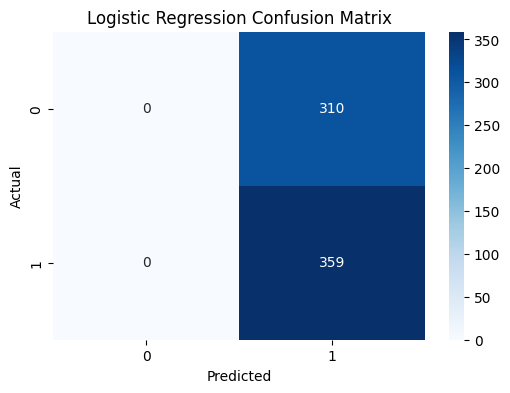

In [43]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_class)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [44]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Polynomial Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Logistic Regression"
    ],
    "Metric": [
        rmse,
        rmse_poly,
        rmse_ridge,
        rmse_lasso,
        accuracy
    ]
})

results

,Model,Metric
0,Linear Regression,0.014849
1,Polynomial Regression,0.014724
2,Ridge Regression,0.498430
3,Lasso Regression,0.498783
4,Logistic Regression,0.536622


In [45]:
mu = df_etf["return"].mean()
sigma = df_etf["return"].std()

print("Mean return:", mu)
print("Volatility:", sigma)

Mean return: 0.00035792635147909545
Volatility: 0.016356786771576926


In [46]:
import numpy as np

S0 = df_etf["adj_close"].iloc[-1]

T = 252       # trading days in 1 year
dt = 1/252
n_simulations = 100

price_paths = np.zeros((T, n_simulations))

for i in range(n_simulations):
    
    prices = [S0]
    
    for t in range(1, T):
        
        shock = np.random.normal(mu*dt, sigma*np.sqrt(dt))
        price = prices[-1] * np.exp(shock)
        
        prices.append(price)
    
    price_paths[:, i] = prices

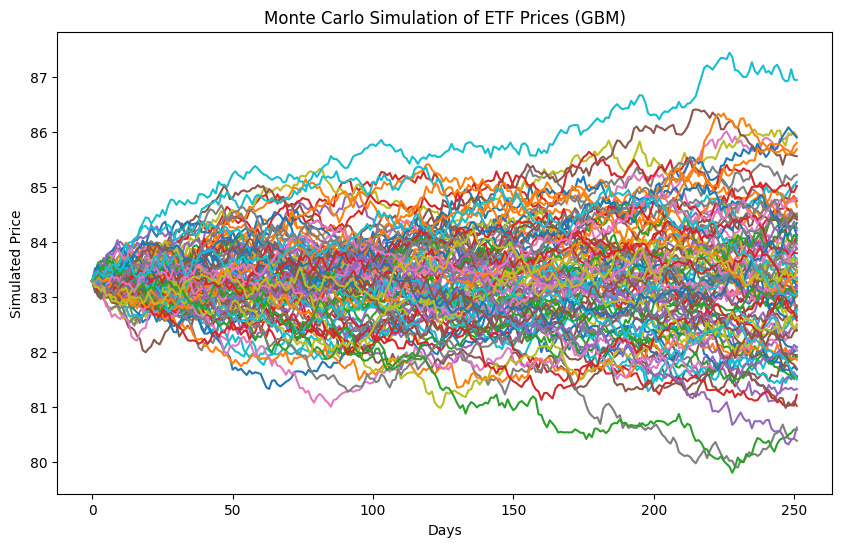

In [47]:
plt.figure(figsize=(10,6))

plt.plot(price_paths)

plt.title("Monte Carlo Simulation of ETF Prices (GBM)")
plt.xlabel("Days")
plt.ylabel("Simulated Price")

plt.show()

In [48]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Polynomial Regression",
        "Logistic Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],
    "Key Metric": [
        rmse,
        rmse_poly,
        accuracy,
        rmse_ridge,
        rmse_lasso
    ],
    "Metric Type": [
        "RMSE",
        "RMSE",
        "Accuracy",
        "RMSE",
        "RMSE"
    ]
})

results

,Model,Key Metric,Metric Type
0,Linear Regression,0.014849,RMSE
1,Polynomial Regression,0.014724,RMSE
2,Logistic Regression,0.536622,Accuracy
3,Ridge Regression,0.498430,RMSE
4,Lasso Regression,0.498783,RMSE
